# CardioTwin Dataset Audit and Preprocessing Design

IIT Multimodal AI Hackathon 2026 Track A

This notebook audits the `extention of Z-Alizadeh sani dataset.xlsx` workbook for dataset understanding, statistical analysis, cleaning, leakage review, and preprocessing design. It does **not** train final ML models, tune models, perform data augmentation, or perform global feature selection.

Hackathon targets:

- Overall CAD
- LAD stenosis
- LCX stenosis
- RCA stenosis

Critical leakage rule: `LAD`, `LCX`, `RCA`, and `Cath` are treated only as ground-truth target variables and are never used as predictor features.

In [1]:
# 1. Setup
from __future__ import annotations

import json
import math
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

DATASET_FILENAME = "extention of Z-Alizadeh sani dataset.xlsx"

def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root by looking for ml/data/raw from the current notebook location."""
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "ml" / "data" / "raw").exists():
            return candidate
        if candidate.name == "ml" and (candidate / "data" / "raw").exists():
            return candidate.parent
    raise FileNotFoundError("Could not locate project root containing ml/data/raw.")

PROJECT_ROOT = find_project_root()
ML_DIR = PROJECT_ROOT / "ml"
RAW_DATA_DIR = ML_DIR / "data" / "raw"
PROCESSED_DATA_DIR = ML_DIR / "data" / "processed"
DATASET_PATH = RAW_DATA_DIR / DATASET_FILENAME

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATASET_PATH.relative_to(PROJECT_ROOT)}")
assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"

excel_file = pd.ExcelFile(DATASET_PATH)
print(f"Workbook sheets: {excel_file.sheet_names}")

df_raw = pd.read_excel(DATASET_PATH, sheet_name=0)
df = df_raw.copy()
print(f"Loaded shape: {df.shape}")

Project root: C:\Users\samri\cod\git\IIT_Mandi\cardio-3d-ai
Dataset path: ml\data\raw\extention of Z-Alizadeh sani dataset.xlsx
Workbook sheets: ['Sheet 1 - Table 1', 'Sheet1']


Loaded shape: (303, 59)


## 2. Basic Data Audit

This section inspects the raw table structure, column names, data types, missingness, duplicates, unique values, and constant or near-constant variables. No rows or columns are removed here.

In [2]:
original_shape = df.shape

print("Dataset shape:", df.shape)
display(df.head())

columns_df = pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str).values})
display(columns_df)

print("All column names:")
for idx, col in enumerate(df.columns, start=1):
    print(f"{idx:02d}. {col}")

duplicate_count = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_count}")
if duplicate_count:
    display(df[df.duplicated(keep=False)].head(20))

missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100,
    })
    .sort_values(["missing_count", "missing_percent"], ascending=False)
)
display(missing_summary)

unique_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique_count": df.nunique(dropna=False),
    "sample_values": [df[col].dropna().unique()[:10].tolist() for col in df.columns],
})
display(unique_summary)

constant_features = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
near_constant_rows = []
for col in df.columns:
    counts = df[col].value_counts(dropna=False, normalize=True)
    top_ratio = float(counts.iloc[0]) if not counts.empty else np.nan
    if top_ratio >= 0.95 and col not in constant_features:
        near_constant_rows.append({"feature": col, "top_frequency_ratio": top_ratio, "unique_count": df[col].nunique(dropna=False)})
near_constant_features = pd.DataFrame(near_constant_rows).sort_values("top_frequency_ratio", ascending=False)

print("Constant features:", constant_features)
display(near_constant_features)

Dataset shape: (303, 59)


,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,Obesity,CRF,CVA,Airway disease,Thyroid Disease,CHF,DLP,BP,PR,Edema,Weak Peripheral Pulse,Lung rales,Systolic Murmur,Diastolic Murmur,Typical Chest Pain,Dyspnea,Function Class,Atypical,Nonanginal,Exertional CP,LowTH Ang,Q Wave,St Elevation,St Depression,Tinversion,LVH,Poor R Progression,BBB,FBS,CR,TG,LDL,HDL,BUN,ESR,HB,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,LAD,LCX,RCA,Cath
0,53,90,175,Male,29.388,0,1,1,0,0,Y,N,N,N,N,N,Y,110,80,0,N,N,N,N,0,N,0,N,N,N,N,0,0,1,1,N,N,N,90,0.700,250,155,30.000,8,7,15.600,4.700,141,5700,39,52,261,50,0,N,Stenotic,Normal,Stenotic,CAD
1,67,70,157,Fmale,28.399,0,1,0,0,0,Y,N,N,N,N,N,N,140,80,1,N,N,N,N,1,N,0,N,N,N,N,0,0,1,1,N,N,N,80,1.000,309,121,36.000,30,26,13.900,4.700,156,7700,38,55,165,40,4,N,Stenotic,Stenotic,Normal,CAD
2,54,54,164,Male,20.077,0,0,1,0,0,N,N,N,N,N,N,N,100,100,0,N,N,N,N,1,N,0,N,N,N,N,0,0,0,0,N,N,N,85,1.000,103,70,45.000,17,10,13.500,4.700,139,7400,38,60,230,40,2,mild,Stenotic,Normal,Normal,CAD
3,66,67,158,Fmale,26.839,0,1,0,0,0,Y,N,N,N,N,N,N,100,80,0,N,N,N,Y,0,Y,3,N,Y,N,N,0,0,1,0,N,N,N,78,1.200,63,55,27.000,30,76,12.100,4.400,142,13000,18,72,742,55,0,Severe,Normal,Normal,Normal,Normal
4,50,87,153,Fmale,37.165,0,1,0,0,0,Y,N,N,N,N,N,N,110,80,0,N,N,Y,N,0,Y,2,N,N,N,N,0,0,0,0,N,N,N,104,1.000,170,110,50.000,16,27,13.200,4.000,140,9200,55,39,274,50,0,Severe,Normal,Normal,Normal,Normal


,column,dtype
0,Age,int64
1,Weight,int64
2,Length,int64
3,Sex,str
4,BMI,float64
5,DM,int64
6,HTN,int64
7,Current Smoker,int64
8,EX-Smoker,int64
9,FH,int64


All column names:
01. Age
02. Weight
03. Length
04. Sex
05. BMI
06. DM
07. HTN
08. Current Smoker
09. EX-Smoker
10. FH
11. Obesity
12. CRF
13. CVA
14. Airway disease
15. Thyroid Disease
16. CHF
17. DLP
18. BP
19. PR
20. Edema
21. Weak Peripheral Pulse
22. Lung rales
23. Systolic Murmur
24. Diastolic Murmur
25. Typical Chest Pain
26. Dyspnea
27. Function Class
28. Atypical
29. Nonanginal
30. Exertional CP
31. LowTH Ang
32. Q Wave
33. St Elevation
34. St Depression
35. Tinversion
36. LVH
37. Poor R Progression
38. BBB
39. FBS
40. CR
41. TG
42. LDL
43. HDL
44. BUN
45. ESR
46. HB
47. K
48. Na
49. WBC
50. Lymph
51. Neut
52. PLT
53. EF-TTE
54. Region RWMA
55. VHD
56. LAD
57. LCX
58. RCA
59. Cath
Duplicate rows: 0


,missing_count,missing_percent
Age,0,0.000
Weight,0,0.000
Length,0,0.000
Sex,0,0.000
BMI,0,0.000
DM,0,0.000
HTN,0,0.000
Current Smoker,0,0.000
EX-Smoker,0,0.000
FH,0,0.000


,dtype,unique_count,sample_values
Age,int64,46,"[53, 67, 54, 66, 50, 55, 72, 58, 60, 80]"
Weight,int64,54,"[90, 70, 54, 67, 87, 75, 80, 84, 71, 63]"
Length,int64,44,"[175, 157, 164, 158, 153, 165, 163, 170, 168, ..."
Sex,str,2,"[Male, Fmale]"
BMI,float64,263,"[29.387755102040817, 28.398718000730252, 20.07..."
DM,int64,2,"[0, 1]"
HTN,int64,2,"[1, 0]"
Current Smoker,int64,2,"[1, 0]"
EX-Smoker,int64,2,"[0, 1]"
FH,int64,2,"[0, 1]"


Constant features: ['Exertional CP']


,feature,top_frequency_ratio,unique_count
5,CHF,0.997,2
10,LowTH Ang,0.993,2
7,Weak Peripheral Pulse,0.983,2
2,CVA,0.983,2
1,CRF,0.980,2
4,Thyroid Disease,0.977,2
9,Diastolic Murmur,0.970,2
12,Poor R Progression,0.970,2
0,EX-Smoker,0.967,2
3,Airway disease,0.964,2


## 3. Target Audit

The workbook represents overall CAD in `Cath`, where `CAD` means positive and `Normal` means negative. Artery stenosis labels are represented by `LAD`, `LCX`, and `RCA`, where `Stenotic` means positive and `Normal` means negative. These four columns are ground truth only and are excluded from predictors.

Target CAD source column: Cath


,count
Cath,
CAD,216
Normal,87


Target LAD source column: LAD


,count
LAD,
Stenotic,177
Normal,126


Target LCX source column: LCX


,count
LCX,
Normal,184
Stenotic,119


Target RCA source column: RCA


,count
RCA,
Normal,189
Stenotic,114


CAD raw labels: ['CAD', 'Normal']
LAD raw labels: ['Normal', 'Stenotic']
LCX raw labels: ['Normal', 'Stenotic']
RCA raw labels: ['Normal', 'Stenotic']


,target,class,count,percent
0,cad,0,87,28.713
1,cad,1,216,71.287
2,lad,0,126,41.584
3,lad,1,177,58.416
4,lcx,0,184,60.726
5,lcx,1,119,39.274
6,rca,0,189,62.376
7,rca,1,114,37.624


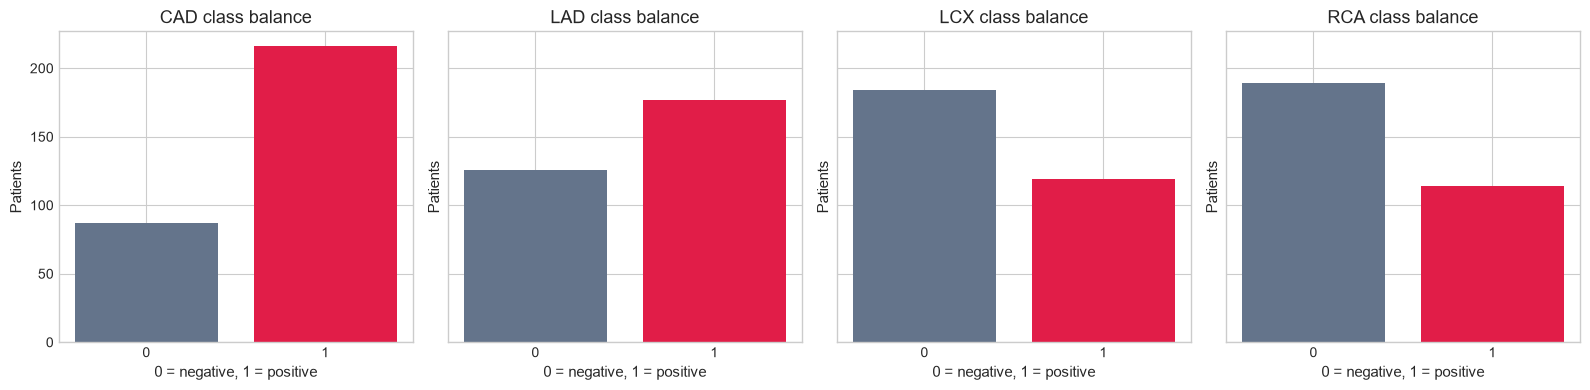

Invalid mapped target labels: {'cad': 0, 'lad': 0, 'lcx': 0, 'rca': 0}


In [3]:
TARGET_SOURCE_COLUMNS = {
    "cad": "Cath",
    "lad": "LAD",
    "lcx": "LCX",
    "rca": "RCA",
}

TARGET_LABEL_MAPS = {
    "cad": {"Normal": 0, "CAD": 1},
    "lad": {"Normal": 0, "Stenotic": 1},
    "lcx": {"Normal": 0, "Stenotic": 1},
    "rca": {"Normal": 0, "Stenotic": 1},
}

def normalize_label(value: object) -> object:
    if pd.isna(value):
        return np.nan
    return str(value).strip()

def map_target(series: pd.Series, label_map: dict[str, int], target_name: str) -> pd.Series:
    normalized = series.map(normalize_label)
    observed = set(normalized.dropna().unique())
    expected = set(label_map.keys())
    unexpected = observed - expected
    missing_expected = expected - observed
    print(f"{target_name.upper()} raw labels: {sorted(observed)}")
    assert not unexpected, f"Unexpected labels in {target_name}: {unexpected}"
    if missing_expected:
        print(f"Note: expected labels not observed for {target_name}: {sorted(missing_expected)}")
    mapped = normalized.map(label_map)
    assert mapped.notna().all(), f"Missing or unmapped labels found in {target_name}"
    return mapped.astype("int8")

for target_name, col in TARGET_SOURCE_COLUMNS.items():
    print("=" * 80)
    print(f"Target {target_name.upper()} source column: {col}")
    display(df[col].value_counts(dropna=False).rename("count").to_frame())

y_cad = map_target(df[TARGET_SOURCE_COLUMNS["cad"]], TARGET_LABEL_MAPS["cad"], "cad")
y_lad = map_target(df[TARGET_SOURCE_COLUMNS["lad"]], TARGET_LABEL_MAPS["lad"], "lad")
y_lcx = map_target(df[TARGET_SOURCE_COLUMNS["lcx"]], TARGET_LABEL_MAPS["lcx"], "lcx")
y_rca = map_target(df[TARGET_SOURCE_COLUMNS["rca"]], TARGET_LABEL_MAPS["rca"], "rca")

targets = pd.DataFrame({"cad": y_cad, "lad": y_lad, "lcx": y_lcx, "rca": y_rca}, index=df.index)

target_balance = []
for col in targets.columns:
    counts = targets[col].value_counts().sort_index()
    percentages = targets[col].value_counts(normalize=True).sort_index() * 100
    for label in [0, 1]:
        target_balance.append({"target": col, "class": label, "count": int(counts.get(label, 0)), "percent": float(percentages.get(label, 0.0))})
target_balance_df = pd.DataFrame(target_balance)
display(target_balance_df)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, target in zip(axes, targets.columns):
    counts = targets[target].value_counts().reindex([0, 1], fill_value=0)
    ax.bar(["0", "1"], counts.values, color=["#64748b", "#e11d48"])
    ax.set_title(f"{target.upper()} class balance")
    ax.set_xlabel("0 = negative, 1 = positive")
    ax.set_ylabel("Patients")
plt.tight_layout()
plt.show()

invalid_target_counts = {col: int((~targets[col].isin([0, 1])).sum()) for col in targets.columns}
print("Invalid mapped target labels:", invalid_target_counts)
assert all(count == 0 for count in invalid_target_counts.values())

## 4. Feature Audit

Variables are classified using both dtype and semantics. Many clinical variables are numerically encoded binary or ordinal categories, so dtype alone is not used to decide feature type.

In [4]:
TARGET_COLUMNS = list(TARGET_SOURCE_COLUMNS.values())
FORBIDDEN_COLUMNS = ["LAD", "LCX", "RCA", "Cath"]

NUMERIC_FEATURES = [
    "Age", "Weight", "Length", "BMI", "BP", "PR", "FBS", "CR", "TG", "LDL", "HDL", "BUN", "ESR", "HB", "K", "Na", "WBC", "Lymph", "Neut", "PLT", "EF-TTE",
]

CATEGORICAL_FEATURES = [
    "Sex", "DM", "HTN", "Current Smoker", "EX-Smoker", "FH", "Obesity", "CRF", "CVA", "Airway disease", "Thyroid Disease", "CHF", "DLP", "Edema", "Weak Peripheral Pulse", "Lung rales", "Systolic Murmur", "Diastolic Murmur", "Typical Chest Pain", "Dyspnea", "Function Class", "Atypical", "Nonanginal", "Exertional CP", "LowTH Ang", "Q Wave", "St Elevation", "St Depression", "Tinversion", "LVH", "Poor R Progression", "BBB", "Region RWMA", "VHD",
]

all_feature_columns = NUMERIC_FEATURES + CATEGORICAL_FEATURES
unknown_columns = sorted(set(df.columns) - set(all_feature_columns) - set(FORBIDDEN_COLUMNS))
missing_listed_columns = sorted(set(all_feature_columns + FORBIDDEN_COLUMNS) - set(df.columns))
assert not unknown_columns, f"Unclassified columns remain: {unknown_columns}"
assert not missing_listed_columns, f"Listed columns not found in dataset: {missing_listed_columns}"
assert not (set(NUMERIC_FEATURES) & set(CATEGORICAL_FEATURES)), "Feature appears in both numeric and categorical lists."

print(f"TARGET_COLUMNS: {TARGET_COLUMNS}")
print(f"FORBIDDEN_COLUMNS: {FORBIDDEN_COLUMNS}")
print(f"NUMERIC_FEATURES ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"CATEGORICAL_FEATURES ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

metadata_rows = []
for col in all_feature_columns:
    series = df[col]
    is_numeric_feature = col in NUMERIC_FEATURES
    row = {
        "feature": col,
        "dtype": str(series.dtype),
        "feature_type": "numeric" if is_numeric_feature else "categorical_or_binary",
        "unique_count": int(series.nunique(dropna=False)),
        "missing_count": int(series.isna().sum()),
        "min": np.nan,
        "max": np.nan,
        "mean": np.nan,
        "median": np.nan,
    }
    if is_numeric_feature:
        numeric_series = pd.to_numeric(series, errors="coerce")
        row.update({"min": numeric_series.min(), "max": numeric_series.max(), "mean": numeric_series.mean(), "median": numeric_series.median()})
    metadata_rows.append(row)

feature_metadata = pd.DataFrame(metadata_rows)
display(feature_metadata)

TARGET_COLUMNS: ['Cath', 'LAD', 'LCX', 'RCA']
FORBIDDEN_COLUMNS: ['LAD', 'LCX', 'RCA', 'Cath']
NUMERIC_FEATURES (21): ['Age', 'Weight', 'Length', 'BMI', 'BP', 'PR', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE']
CATEGORICAL_FEATURES (34): ['Sex', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'Obesity', 'CRF', 'CVA', 'Airway disease', 'Thyroid Disease', 'CHF', 'DLP', 'Edema', 'Weak Peripheral Pulse', 'Lung rales', 'Systolic Murmur', 'Diastolic Murmur', 'Typical Chest Pain', 'Dyspnea', 'Function Class', 'Atypical', 'Nonanginal', 'Exertional CP', 'LowTH Ang', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'LVH', 'Poor R Progression', 'BBB', 'Region RWMA', 'VHD']


,feature,dtype,feature_type,unique_count,missing_count,min,max,mean,median
0,Age,int64,numeric,46,0,30.000,86.000,58.898,58.000
1,Weight,int64,numeric,54,0,48.000,120.000,73.832,74.000
2,Length,int64,numeric,44,0,140.000,188.000,164.716,165.000
3,BMI,float64,numeric,263,0,18.115,40.901,27.248,26.776
4,BP,int64,numeric,17,0,90.000,190.000,129.554,130.000
5,PR,int64,numeric,21,0,50.000,110.000,75.142,70.000
6,FBS,int64,numeric,113,0,62.000,400.000,119.185,98.000
7,CR,float64,numeric,18,0,0.500,2.200,1.056,1.000
8,TG,int64,numeric,147,0,37.000,1050.000,150.343,122.000
9,LDL,int64,numeric,110,0,18.000,232.000,104.644,100.000


## 5. Data Quality and Statistical Analysis

Clinical outliers are flagged for review and are not automatically deleted. Extreme values may represent true high-risk patients.

,count,mean,std,min,25%,50%,75%,max,missing_count,skewness
Age,303.000,58.898,10.392,30.000,51.000,58.000,66.000,86.000,0,0.135
Weight,303.000,73.832,11.987,48.000,65.000,74.000,81.000,120.000,0,0.419
Length,303.000,164.716,9.328,140.000,158.000,165.000,171.000,188.000,0,-0.032
BMI,303.000,27.248,4.099,18.115,24.514,26.776,29.412,40.901,0,0.434
BP,303.000,129.554,18.938,90.000,120.000,130.000,140.000,190.000,0,0.573
PR,303.000,75.142,8.912,50.000,70.000,70.000,80.000,110.000,0,1.079
FBS,303.000,119.185,52.080,62.000,88.500,98.000,130.000,400.000,0,2.276
CR,303.000,1.056,0.264,0.500,0.900,1.000,1.200,2.200,0,0.950
TG,303.000,150.343,97.959,37.000,90.000,122.000,177.000,1050.000,0,3.782
LDL,303.000,104.644,35.397,18.000,80.000,100.000,122.000,232.000,0,0.571


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count
6,FBS,88.500,130.000,41.500,26.250,192.250,30
11,BUN,13.000,20.000,7.000,2.500,30.500,17
8,TG,90.000,177.000,87.000,-40.500,307.500,16
15,Na,139.000,143.000,4.000,133.000,149.000,15
20,EF-TTE,45.000,55.000,10.000,30.000,70.000,15
12,ESR,9.000,26.000,17.000,-16.500,51.500,13
5,PR,70.000,80.000,10.000,55.000,95.000,13
19,PLT,183.500,250.000,66.500,83.750,349.750,11
16,WBC,5800.000,8800.000,3000.000,1300.000,13300.000,9
4,BP,120.000,140.000,20.000,90.000,170.000,9


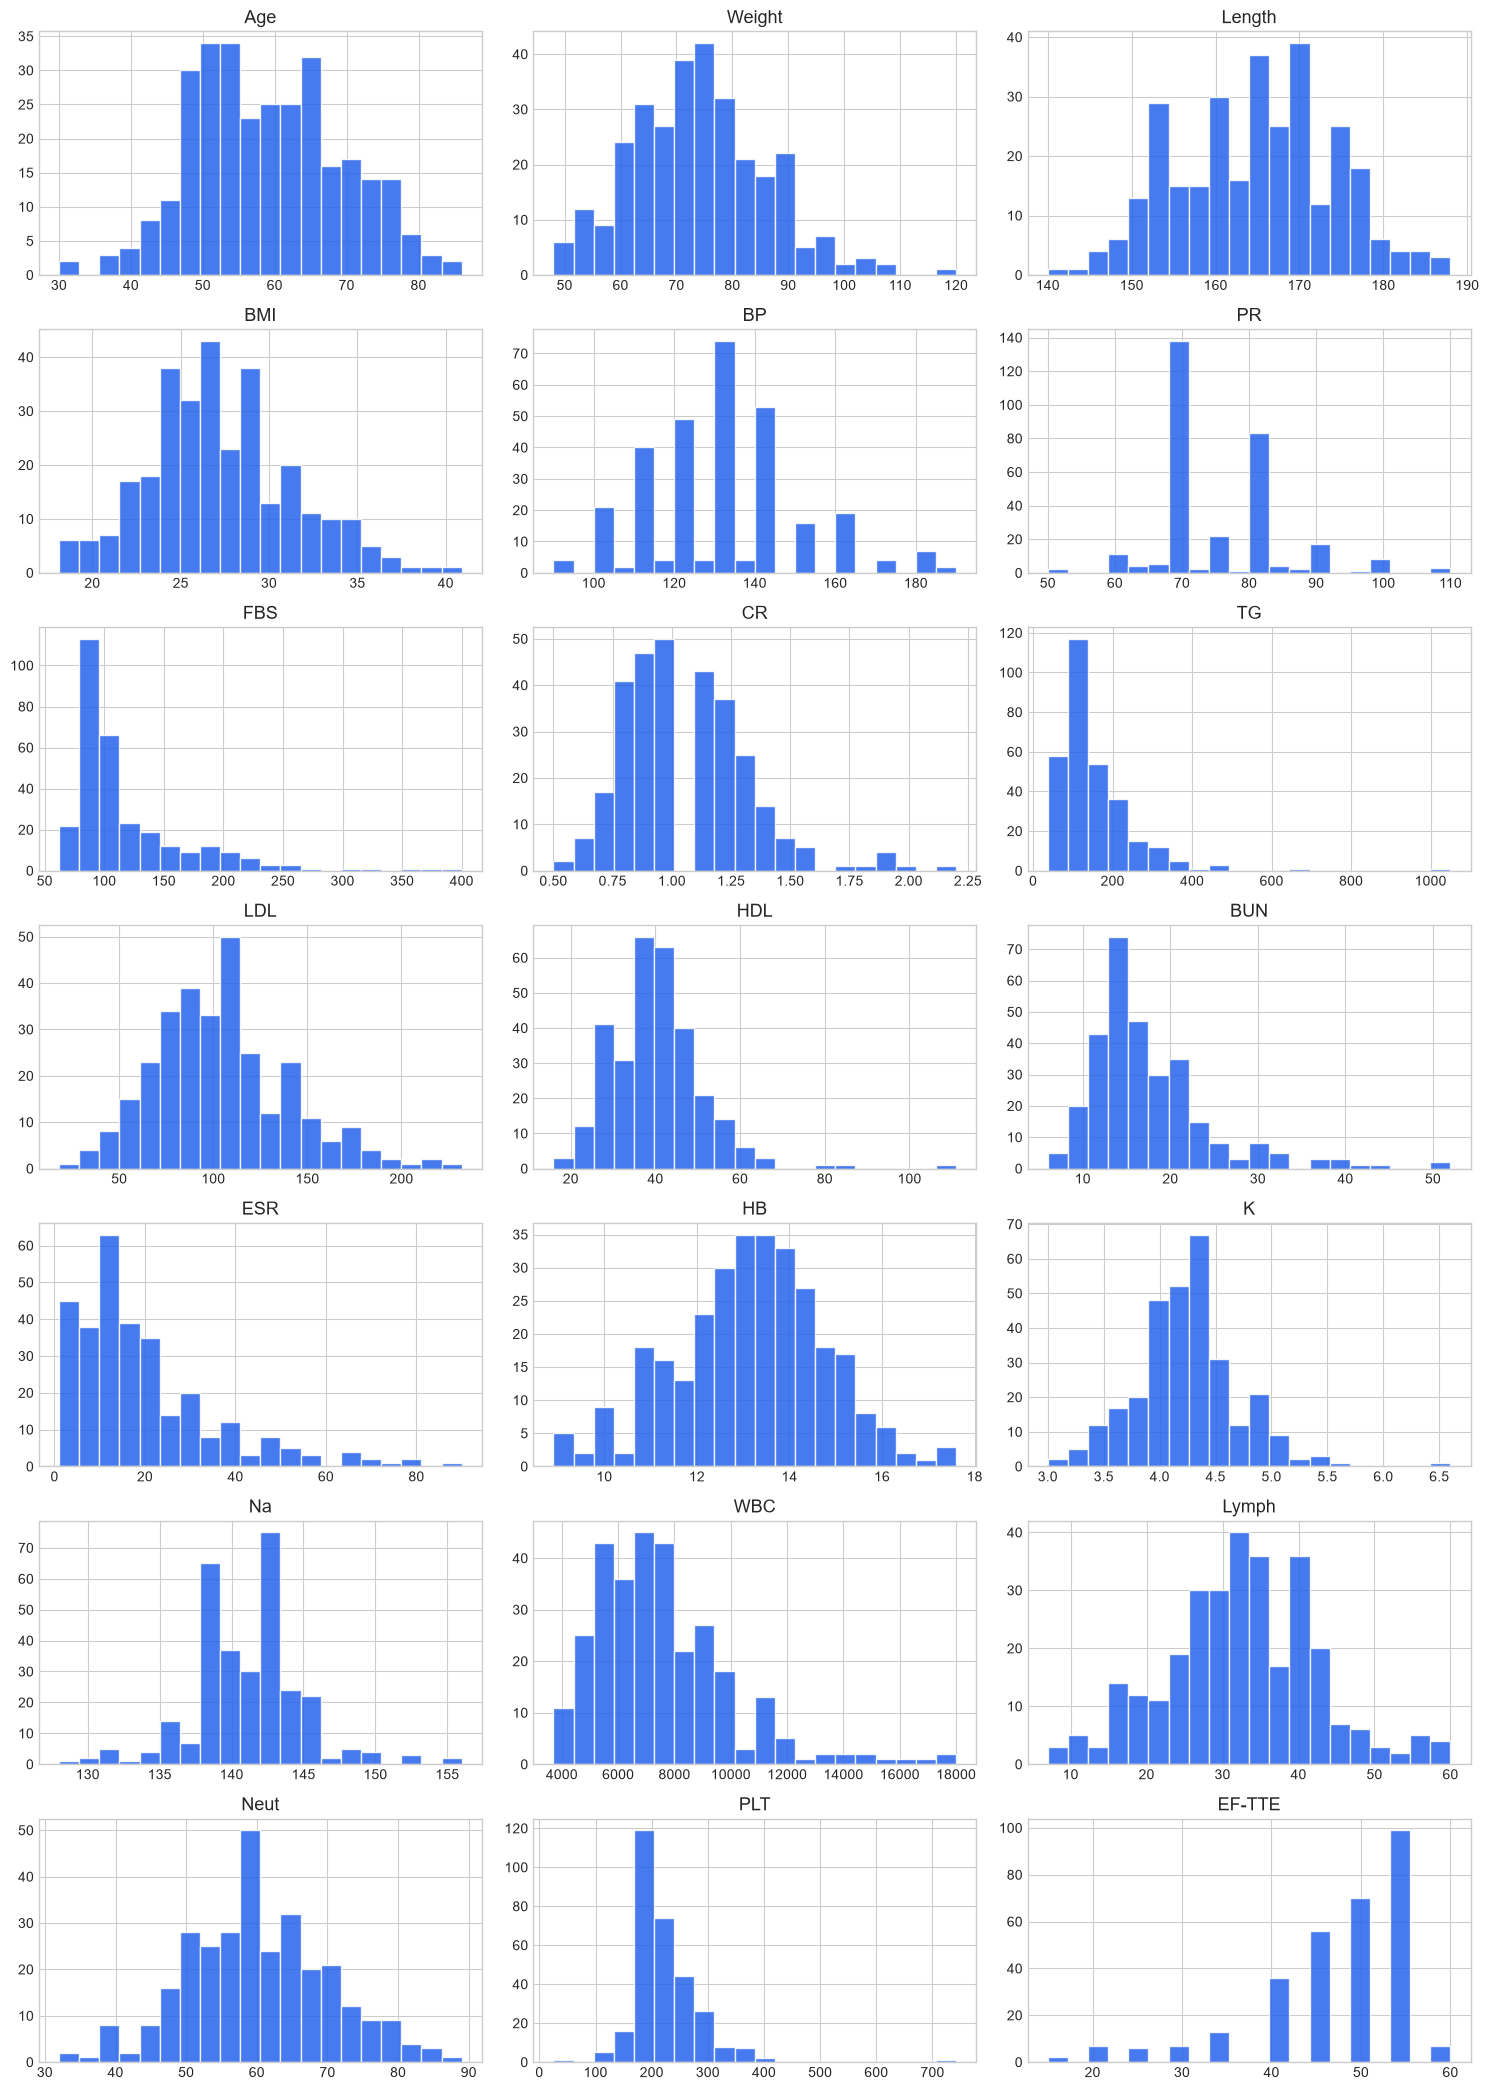

Sex


,category,count,percent
0,Male,176,58.086
1,Fmale,127,41.914


DM


,category,count,percent
0,0,213,70.297
1,1,90,29.703


HTN


...

Region RWMA


,category,count,percent
0,0,217,71.617
1,2,32,10.561
2,1,26,8.581
3,4,14,4.620
4,3,14,4.620


VHD


,category,count,percent
0,mild,149,49.175
1,N,116,38.284
2,Moderate,27,8.911
3,Severe,11,3.630


,feature,category,count,percent
3,Airway disease,Y,11,3.630
15,BBB,RBBB,8,2.640
14,BBB,LBBB,13,4.290
5,CHF,Y,1,0.330
1,CRF,Y,6,1.980
2,CVA,Y,5,1.650
9,Diastolic Murmur,Y,9,2.970
0,EX-Smoker,1,10,3.300
6,Edema,1,12,3.960
10,Function Class,1,1,0.330


In [5]:
numeric_df = df[NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce")

numeric_descriptive = numeric_df.describe().T
numeric_descriptive["missing_count"] = numeric_df.isna().sum()
numeric_descriptive["skewness"] = numeric_df.skew(numeric_only=True)
display(numeric_descriptive)

outlier_rows = []
for col in NUMERIC_FEATURES:
    series = numeric_df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((series < lower) | (series > upper)).sum())
    outlier_rows.append({"feature": col, "q1": q1, "q3": q3, "iqr": iqr, "lower_bound": lower, "upper_bound": upper, "outlier_count": count})
outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_summary)

plot_features = NUMERIC_FEATURES[:]
n_cols = 3
n_rows = math.ceil(len(plot_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, n_rows * 3)))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, plot_features):
    ax.hist(numeric_df[col].dropna(), bins=20, color="#2563eb", alpha=0.85, edgecolor="white")
    ax.set_title(col)
for ax in axes[len(plot_features):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

category_tables = {}
rare_category_rows = []
for col in CATEGORICAL_FEATURES:
    counts = df[col].astype("string").fillna("<MISSING>").value_counts(dropna=False)
    percents = df[col].astype("string").fillna("<MISSING>").value_counts(normalize=True, dropna=False) * 100
    table = pd.DataFrame({"count": counts, "percent": percents}).rename_axis("category").reset_index()
    category_tables[col] = table
    rare = table[table["percent"] < 5].copy()
    rare["feature"] = col
    rare_category_rows.append(rare[["feature", "category", "count", "percent"]])

for col in CATEGORICAL_FEATURES:
    print("=" * 80)
    print(col)
    display(category_tables[col])

rare_categories = pd.concat(rare_category_rows, ignore_index=True) if rare_category_rows else pd.DataFrame(columns=["feature", "category", "count", "percent"])
display(rare_categories.sort_values(["feature", "percent"]))

## 6. Relationship Analysis

These analyses are exploratory only. They are useful for understanding the dataset, but they must not be used as global feature selection for later model evaluation. Future modeling should fit preprocessing and any feature selection inside cross-validation folds or training data only.

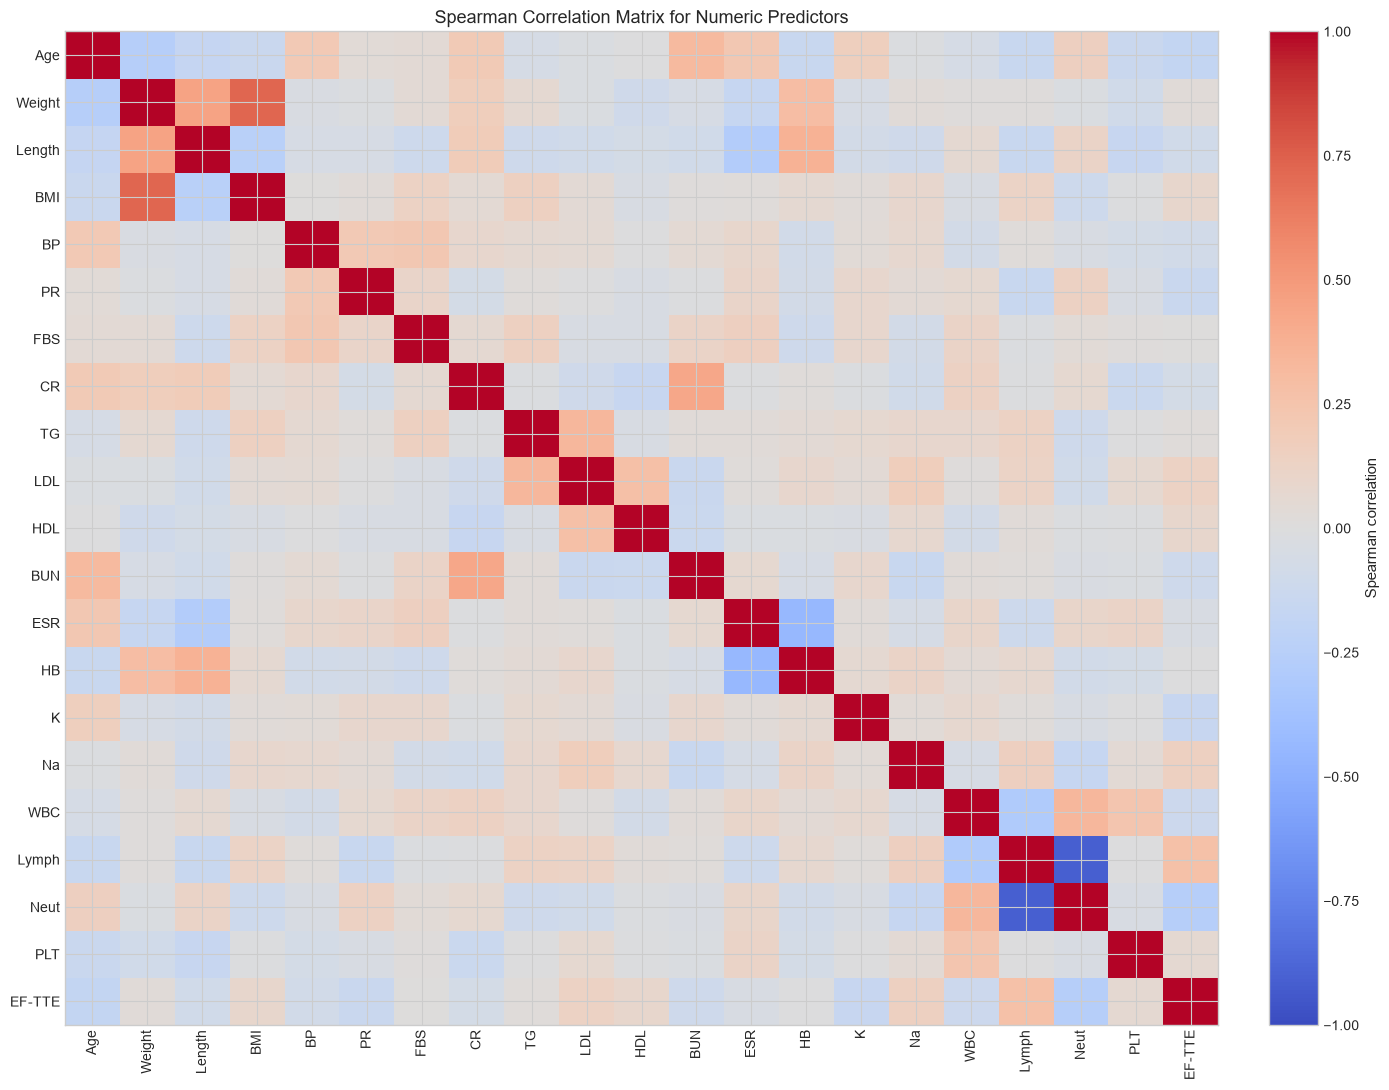

,feature_a,feature_b,spearman_corr
0,Lymph,Neut,-0.912


,target,feature,test,statistic,p_value,class0_median,class1_median
0,cad,Age,Mann-Whitney U,5188.500,0.000,52.000,61.500
20,cad,EF-TTE,Mann-Whitney U,12909.500,0.000,55.000,45.500
4,cad,BP,Mann-Whitney U,6363.000,0.000,120.000,130.000
6,cad,FBS,Mann-Whitney U,6553.500,0.000,92.000,103.000
12,cad,ESR,Mann-Whitney U,6879.500,0.000,12.000,16.000
8,cad,TG,Mann-Whitney U,7178.500,0.001,110.000,130.000
14,cad,K,Mann-Whitney U,7241.000,0.002,4.100,4.300
5,cad,PR,Mann-Whitney U,7472.000,0.003,70.000,74.000
17,cad,Lymph,Mann-Whitney U,10892.500,0.030,34.000,31.500
18,cad,Neut,Mann-Whitney U,7910.500,0.031,58.000,60.000


,target,feature,test,statistic,p_value,dof
18,cad,Typical Chest Pain,Chi-square,86.936,0.000,1.000
21,cad,Atypical,Chi-square,50.442,0.000,1.000
32,cad,Region RWMA,Chi-square,34.901,0.000,4.000
2,cad,HTN,Chi-square,23.813,0.000,1.000
22,cad,Nonanginal,Chi-square,20.149,0.000,1.000
1,cad,DM,Chi-square,18.175,0.000,1.000
28,cad,Tinversion,Chi-square,15.883,0.000,1.000
33,cad,VHD,Chi-square,16.198,0.001,3.000
27,cad,St Depression,Chi-square,5.589,0.018,1.000
25,cad,Q Wave,Chi-square,5.403,0.020,1.000


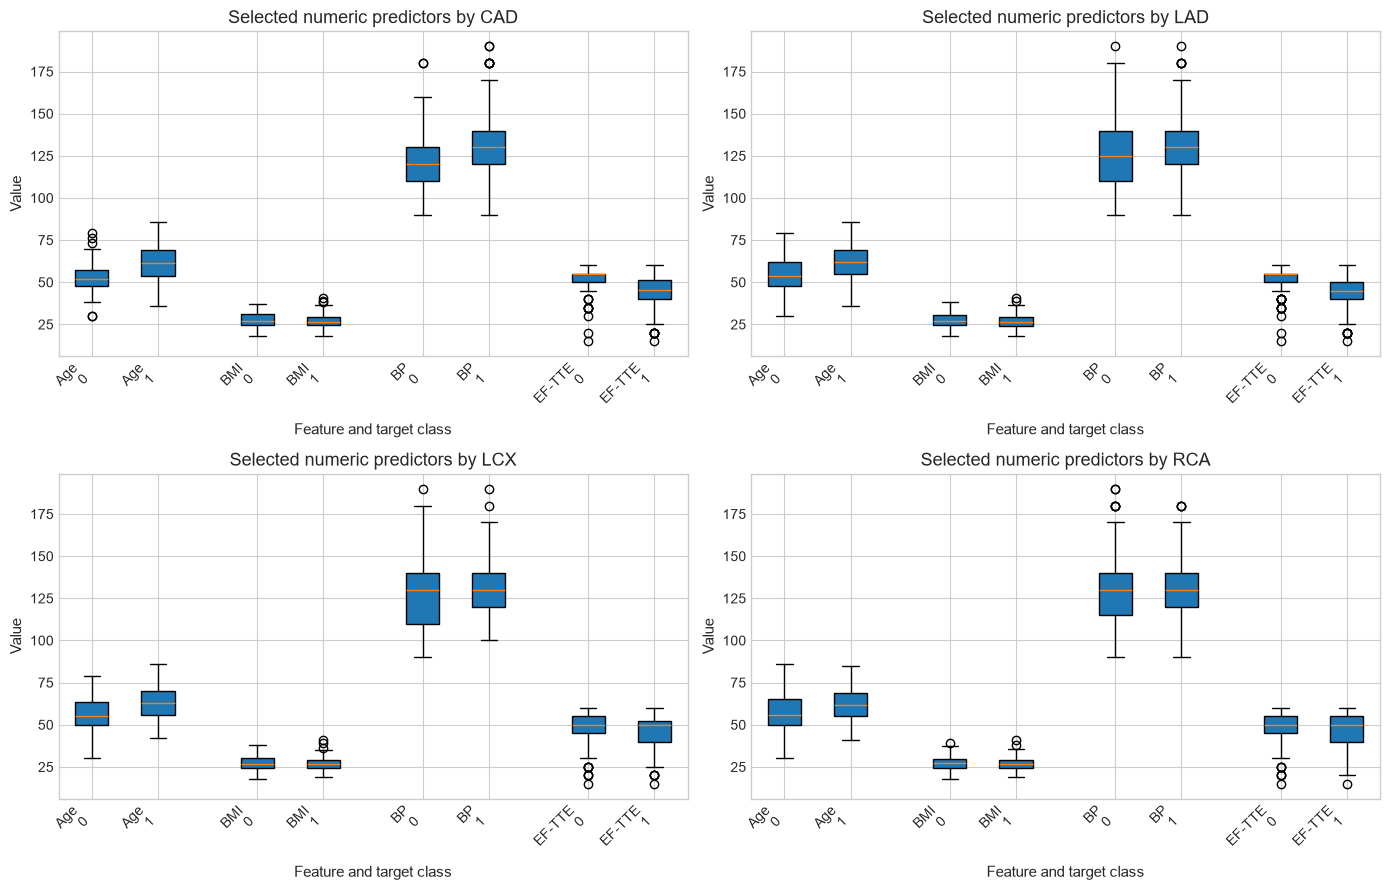

In [6]:
corr_matrix = numeric_df.corr(method="spearman")
fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.index)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")
ax.set_title("Spearman Correlation Matrix for Numeric Predictors")
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i, col_a in enumerate(corr_matrix.columns):
    for col_b in corr_matrix.columns[i + 1:]:
        corr_value = corr_matrix.loc[col_a, col_b]
        if pd.notna(corr_value) and abs(corr_value) >= 0.80:
            high_corr_pairs.append({"feature_a": col_a, "feature_b": col_b, "spearman_corr": corr_value})
high_corr_pairs_df = pd.DataFrame(high_corr_pairs).sort_values("spearman_corr", key=lambda s: s.abs(), ascending=False) if high_corr_pairs else pd.DataFrame(columns=["feature_a", "feature_b", "spearman_corr"])
display(high_corr_pairs_df)

def numeric_target_tests(features: pd.DataFrame, target_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for target in target_frame.columns:
        y = target_frame[target]
        for col in features.columns:
            group0 = features.loc[y == 0, col].dropna()
            group1 = features.loc[y == 1, col].dropna()
            if len(group0) < 3 or len(group1) < 3:
                p_value = np.nan
                statistic = np.nan
            else:
                statistic, p_value = stats.mannwhitneyu(group0, group1, alternative="two-sided")
            rows.append({
                "target": target,
                "feature": col,
                "test": "Mann-Whitney U",
                "statistic": statistic,
                "p_value": p_value,
                "class0_median": group0.median() if len(group0) else np.nan,
                "class1_median": group1.median() if len(group1) else np.nan,
            })
    return pd.DataFrame(rows)

def categorical_target_tests(source_df: pd.DataFrame, categorical_features: list[str], target_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for target in target_frame.columns:
        y = target_frame[target]
        for col in categorical_features:
            contingency = pd.crosstab(source_df[col].astype("string").fillna("<MISSING>"), y)
            if contingency.shape[0] < 2 or contingency.shape[1] < 2:
                chi2 = np.nan
                p_value = np.nan
                dof = np.nan
            else:
                chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
            rows.append({"target": target, "feature": col, "test": "Chi-square", "statistic": chi2, "p_value": p_value, "dof": dof})
    return pd.DataFrame(rows)

numeric_relationships = numeric_target_tests(numeric_df, targets)
categorical_relationships = categorical_target_tests(df, CATEGORICAL_FEATURES, targets)

display(numeric_relationships.sort_values(["target", "p_value"]).groupby("target").head(10))
display(categorical_relationships.sort_values(["target", "p_value"]).groupby("target").head(10))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
selected_box_features = ["Age", "BMI", "BP", "EF-TTE"]
for ax, target in zip(axes.reshape(-1), targets.columns):
    positions = []
    labels = []
    box_data = []
    pos = 1
    for feature in selected_box_features:
        for cls in [0, 1]:
            box_data.append(numeric_df.loc[targets[target] == cls, feature].dropna())
            positions.append(pos)
            labels.append(f"{feature}\n{cls}")
            pos += 1
        pos += 0.5
    ax.boxplot(box_data, positions=positions, patch_artist=True)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(f"Selected numeric predictors by {target.upper()}")
    ax.set_xlabel("Feature and target class")
    ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

## 7. Leakage Audit

`LAD`, `LCX`, `RCA`, and `Cath` are excluded from `X`. Remaining column names are inspected for likely post-diagnosis or catheterization-derived leakage. No definite additional catheterization-derived predictor is retained, but echo/imaging-derived variables are flagged for review because their timing relative to diagnosis must be confirmed.

In [7]:
X = df[all_feature_columns].copy()

leakage_intersection = sorted(set(X.columns) & set(FORBIDDEN_COLUMNS))
print("Forbidden columns present in X:", leakage_intersection)
assert not leakage_intersection

name_scan_terms = ["cath", "lad", "lcx", "rca", "sten", "angi", "vessel", "diagnos", "cad"]
name_scan = []
for col in X.columns:
    lowered = col.lower()
    matched_terms = [term for term in name_scan_terms if term in lowered]
    if matched_terms:
        name_scan.append({"column": col, "matched_terms": matched_terms})
name_scan_df = pd.DataFrame(name_scan)
display(name_scan_df if not name_scan_df.empty else pd.DataFrame(columns=["column", "matched_terms"]))

SUSPICIOUS_COLUMNS_REQUIRING_REVIEW = ["EF-TTE", "Region RWMA", "VHD"]
print("Suspicious columns requiring timing/clinical workflow review:", SUSPICIOUS_COLUMNS_REQUIRING_REVIEW)
print("Final candidate predictor list:")
for idx, col in enumerate(X.columns, start=1):
    print(f"{idx:02d}. {col}")

Forbidden columns present in X: []


,column,matched_terms
0,Nonanginal,[angi]


Suspicious columns requiring timing/clinical workflow review: ['EF-TTE', 'Region RWMA', 'VHD']
Final candidate predictor list:
01. Age
02. Weight
03. Length
04. BMI
05. BP
06. PR
07. FBS
08. CR
09. TG
10. LDL
11. HDL
12. BUN
13. ESR
14. HB
15. K
16. Na
17. WBC
18. Lymph
19. Neut
20. PLT
21. EF-TTE
22. Sex
23. DM
24. HTN
25. Current Smoker
26. EX-Smoker
27. FH
28. Obesity
29. CRF
30. CVA
31. Airway disease
32. Thyroid Disease
33. CHF
34. DLP
35. Edema
36. Weak Peripheral Pulse
37. Lung rales
38. Systolic Murmur
39. Diastolic Murmur
40. Typical Chest Pain
41. Dyspnea
42. Function Class
43. Atypical
44. Nonanginal
45. Exertional CP
46. LowTH Ang
47. Q Wave
48. St Elevation
49. St Depression
50. Tinversion
51. LVH
52. Poor R Progression
53. BBB
54. Region RWMA
55. VHD


## 8. Preprocessing Design

These sklearn-compatible definitions are provided for later modeling. They are intentionally **not fit** here. During final model development, preprocessing must be fit inside CV folds or on training data only to avoid leakage.

For linear/distance-based/scaled models, numeric features can be imputed and standardized, while categorical features can be imputed and one-hot encoded. Tree models may not require scaling; CatBoost can often consume categorical features directly if passed with proper categorical feature indices/names.

In [8]:
numeric_preprocessing_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocessing_ohe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

sklearn_preprocessor_scaled_ohe = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessing_scaled, NUMERIC_FEATURES),
        ("categorical", categorical_preprocessing_ohe, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

numeric_preprocessing_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

tree_preprocessor_ohe = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessing_tree, NUMERIC_FEATURES),
        ("categorical", categorical_preprocessing_ohe, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

catboost_feature_plan = {
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "note": "For CatBoost, consider passing raw categorical columns and fitting imputers/encoders only within training folds if needed.",
}

print("Scaled/OHE preprocessor defined but not fit:")
print(sklearn_preprocessor_scaled_ohe)
print("\nTree/OHE preprocessor defined but not fit:")
print(tree_preprocessor_ohe)
print("\nCatBoost feature plan:")
print(json.dumps(catboost_feature_plan, indent=2))

Scaled/OHE preprocessor defined but not fit:
ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Weight', 'Length', 'BMI', 'BP', 'PR',
                                  'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR',
                                  'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut',
                                  'PLT', 'EF-TTE']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),...
                                  'EX-Smoker', 'FH', 'Obesity', 'CRF', 'CVA',
                                  'Airway disease', 'Thyroid Disease', 'CHF',
                                  '

## 9. Prepare Clean Data

Create leakage-safe predictors and four separate binary targets. No train/test split is performed in this notebook.

In [9]:
X = df[all_feature_columns].copy()

y_cad = targets["cad"].copy()
y_lad = targets["lad"].copy()
y_lcx = targets["lcx"].copy()
y_rca = targets["rca"].copy()

targets_clean = pd.DataFrame({"cad": y_cad, "lad": y_lad, "lcx": y_lcx, "rca": y_rca}, index=df.index)

print("X shape:", X.shape)
print("Targets shape:", targets_clean.shape)
display(X.head())
display(targets_clean.head())

X shape: (303, 55)
Targets shape: (303, 4)


,Age,Weight,Length,BMI,BP,PR,FBS,CR,TG,LDL,HDL,BUN,ESR,HB,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Sex,DM,HTN,Current Smoker,EX-Smoker,FH,Obesity,CRF,CVA,Airway disease,Thyroid Disease,CHF,DLP,Edema,Weak Peripheral Pulse,Lung rales,Systolic Murmur,Diastolic Murmur,Typical Chest Pain,Dyspnea,Function Class,Atypical,Nonanginal,Exertional CP,LowTH Ang,Q Wave,St Elevation,St Depression,Tinversion,LVH,Poor R Progression,BBB,Region RWMA,VHD
0,53,90,175,29.388,110,80,90,0.700,250,155,30.000,8,7,15.600,4.700,141,5700,39,52,261,50,Male,0,1,1,0,0,Y,N,N,N,N,N,Y,0,N,N,N,N,0,N,0,N,N,N,N,0,0,1,1,N,N,N,0,N
1,67,70,157,28.399,140,80,80,1.000,309,121,36.000,30,26,13.900,4.700,156,7700,38,55,165,40,Fmale,0,1,0,0,0,Y,N,N,N,N,N,N,1,N,N,N,N,1,N,0,N,N,N,N,0,0,1,1,N,N,N,4,N
2,54,54,164,20.077,100,100,85,1.000,103,70,45.000,17,10,13.500,4.700,139,7400,38,60,230,40,Male,0,0,1,0,0,N,N,N,N,N,N,N,0,N,N,N,N,1,N,0,N,N,N,N,0,0,0,0,N,N,N,2,mild
3,66,67,158,26.839,100,80,78,1.200,63,55,27.000,30,76,12.100,4.400,142,13000,18,72,742,55,Fmale,0,1,0,0,0,Y,N,N,N,N,N,N,0,N,N,N,Y,0,Y,3,N,Y,N,N,0,0,1,0,N,N,N,0,Severe
4,50,87,153,37.165,110,80,104,1.000,170,110,50.000,16,27,13.200,4.000,140,9200,55,39,274,50,Fmale,0,1,0,0,0,Y,N,N,N,N,N,N,0,N,N,Y,N,0,Y,2,N,N,N,N,0,0,0,0,N,N,N,0,Severe


,cad,lad,lcx,rca
0,1,1,0,1
1,1,1,1,0
2,1,1,0,0
3,0,0,0,0
4,0,0,0,0


## 10. Save Clean Intermediate Data

Only clean intermediate CSV files are written to `ml/data/processed/`. No fitted scalers, encoders, or model artifacts are saved.

In [10]:
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

features_path = PROCESSED_DATA_DIR / "features_clean.csv"
targets_path = PROCESSED_DATA_DIR / "targets_clean.csv"
metadata_path = PROCESSED_DATA_DIR / "feature_metadata.csv"

X.to_csv(features_path, index=False)
targets_clean.to_csv(targets_path, index=False)
feature_metadata.to_csv(metadata_path, index=False)

print(f"Saved {features_path.relative_to(PROJECT_ROOT)}")
print(f"Saved {targets_path.relative_to(PROJECT_ROOT)}")
print(f"Saved {metadata_path.relative_to(PROJECT_ROOT)}")

Saved ml\data\processed\features_clean.csv
Saved ml\data\processed\targets_clean.csv
Saved ml\data\processed\feature_metadata.csv


## 11. Quality Checks

In [11]:
assert len(df) == 303, f"Expected 303 patient rows, found {len(df)}. No row removal was justified in this notebook."
assert set(FORBIDDEN_COLUMNS).isdisjoint(X.columns), "Forbidden target/leakage columns found in X."
assert X.index.equals(targets_clean.index), "Target row indices do not align with X."
for col in targets_clean.columns:
    assert set(targets_clean[col].unique()).issubset({0, 1}), f"Target {col} contains values outside 0/1."
assert not any(str(col).lower().startswith("unnamed") for col in X.columns), "Accidental index column found."
assert X.columns.is_unique, "Duplicate feature names found."
assert np.isfinite(X[NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce").to_numpy()).all(), "Infinite values found in numeric predictors."

saved_features = pd.read_csv(features_path)
saved_targets = pd.read_csv(targets_path)
assert not any(str(col).lower().startswith("unnamed") for col in saved_features.columns), "Saved features contain accidental index column."
assert not any(str(col).lower().startswith("unnamed") for col in saved_targets.columns), "Saved targets contain accidental index column."

print("All quality checks passed.")

All quality checks passed.


## 12. Final Summary

In [12]:
summary = {
    "original_shape": original_shape,
    "final_X_shape": X.shape,
    "number_numeric_features": len(NUMERIC_FEATURES),
    "number_categorical_features": len(CATEGORICAL_FEATURES),
    "total_missing_values": int(df.isna().sum().sum()),
    "duplicate_rows": duplicate_count,
    "flagged_outliers_total": int(outlier_summary["outlier_count"].sum()),
    "features_with_outliers": outlier_summary.loc[outlier_summary["outlier_count"] > 0, ["feature", "outlier_count"]].to_dict("records"),
    "highly_correlated_pairs": high_corr_pairs_df.to_dict("records"),
    "target_class_balance": target_balance_df.to_dict("records"),
    "excluded_leakage_columns": FORBIDDEN_COLUMNS,
    "suspicious_columns_requiring_review": SUSPICIOUS_COLUMNS_REQUIRING_REVIEW,
    "constant_features": constant_features,
    "near_constant_features": near_constant_features.to_dict("records") if not near_constant_features.empty else [],
    "processed_outputs": [
        str(features_path.relative_to(PROJECT_ROOT)),
        str(targets_path.relative_to(PROJECT_ROOT)),
        str(metadata_path.relative_to(PROJECT_ROOT)),
    ],
}

print("Preprocessing report:")
print(json.dumps(summary, indent=2, default=str))

Preprocessing report:
{
  "original_shape": [
    303,
    59
  ],
  "final_X_shape": [
    303,
    55
  ],
  "number_numeric_features": 21,
  "number_categorical_features": 34,
  "total_missing_values": 0,
  "duplicate_rows": 0,
  "flagged_outliers_total": 190,
  "features_with_outliers": [
    {
      "feature": "FBS",
      "outlier_count": 30
    },
    {
      "feature": "BUN",
      "outlier_count": 17
    },
    {
      "feature": "TG",
      "outlier_count": 16
    },
    {
      "feature": "Na",
      "outlier_count": 15
    },
    {
      "feature": "EF-TTE",
      "outlier_count": 15
    },
    {
      "feature": "ESR",
      "outlier_count": 13
    },
    {
      "feature": "PR",
      "outlier_count": 13
    },
    {
      "feature": "PLT",
      "outlier_count": 11
    },
    {
      "feature": "WBC",
      "outlier_count": 9
    },
    {
      "feature": "BP",
      "outlier_count": 9
    },
    {
      "feature": "CR",
      "outlier_count": 8
    },
    {
      "featu